In [1]:
import pandas as pd
df = pd.read_csv("customer_data_100k.csv")
df.head()

,Name,Age,City,Purchase_Amount
0,Neha,19,Bangalore,19878
1,Priya,18,Delhi,3756
2,Rahul,57,Mumbai,1652
3,Priya,59,Bangalore,9560
4,Rahul,39,Delhi,10014


In [2]:
print(df.columns.tolist())
print(df.shape)
df.head()

['Name', 'Age', 'City', 'Purchase_Amount']
(100000, 4)


,Name,Age,City,Purchase_Amount
0,Neha,19,Bangalore,19878
1,Priya,18,Delhi,3756
2,Rahul,57,Mumbai,1652
3,Priya,59,Bangalore,9560
4,Rahul,39,Delhi,10014


In [3]:
# Customer Purchase Analysis Project
### By: Palak Saini
### Dataset: 1,00,000 Customer Records

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("customer_data_100k.csv")
print("Dataset loaded successfully!")
print(f"Total Records: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
df.head()

Dataset loaded successfully!
Total Records: 100000
Total Columns: 4


,Name,Age,City,Purchase_Amount
0,Neha,19,Bangalore,19878
1,Priya,18,Delhi,3756
2,Rahul,57,Mumbai,1652
3,Priya,59,Bangalore,9560
4,Rahul,39,Delhi,10014


In [15]:

print(df.isnull().sum())
print(df.duplicated().sum())

Name               0
Age                0
City               0
Purchase_Amount    0
Age_Group          0
dtype: int64
529


In [16]:
df = df.drop_duplicates()
print(f"✅ Duplicates hata diye!")
print(f"Clean Records: {len(df)}")

✅ Duplicates hata diye!
Clean Records: 99471


In [ ]:
Basic Analysis

In [2]:
print("=== BASIC ANALYSIS ===")
print(df.describe())
print("\nCities:", df['City'].unique())

=== BASIC ANALYSIS ===
                 Age  Purchase_Amount
count  100000.000000     100000.00000
mean       38.548070      10046.04601
std        12.104384       5742.08312
min        18.000000        100.00000
25%        28.000000       5054.00000
50%        39.000000      10053.50000
75%        49.000000      15024.00000
max        59.000000      19999.00000

Cities: <StringArray>
['Bangalore', 'Delhi', 'Mumbai']
Length: 3, dtype: str


In [ ]:
City wise Purchase

City
Bangalore    334984682
Delhi        334522988
Mumbai       335096931
Name: Purchase_Amount, dtype: int64


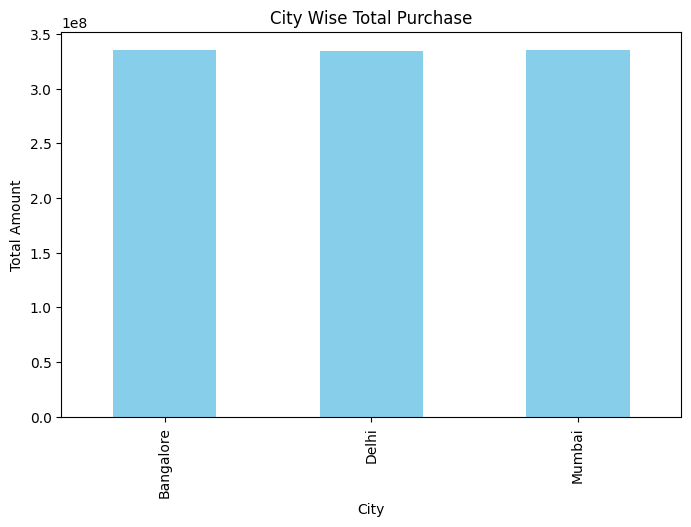

In [5]:
city_sales = df.groupby('City')['Purchase_Amount'].sum()
print(city_sales)

plt.figure(figsize=(8,5))
city_sales.plot(kind='bar', color='skyblue')
plt.title('City Wise Total Purchase')
plt.xlabel('City')
plt.ylabel('Total Amount')
plt.show()

In [ ]:
Age Distribution

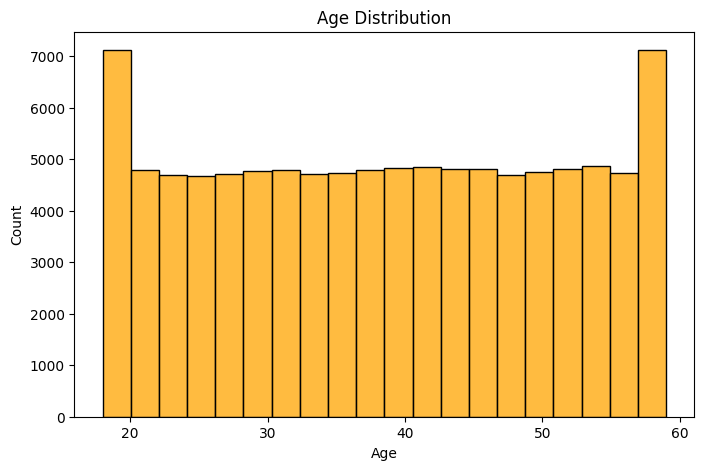

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, color='orange')
plt.title('Age Distribution')
plt.show()

In [ ]:
Top 5 Customers

In [7]:
top5 = df.nlargest(5, 'Purchase_Amount')
print(top5)

        Name  Age       City  Purchase_Amount
20271   Neha   44  Bangalore            19999
37156   Neha   52     Mumbai            19999
46025  Rahul   50      Delhi            19999
90494  Rahul   48  Bangalore            19999
97049   Amit   31      Delhi            19999


In [ ]:
Box Plot

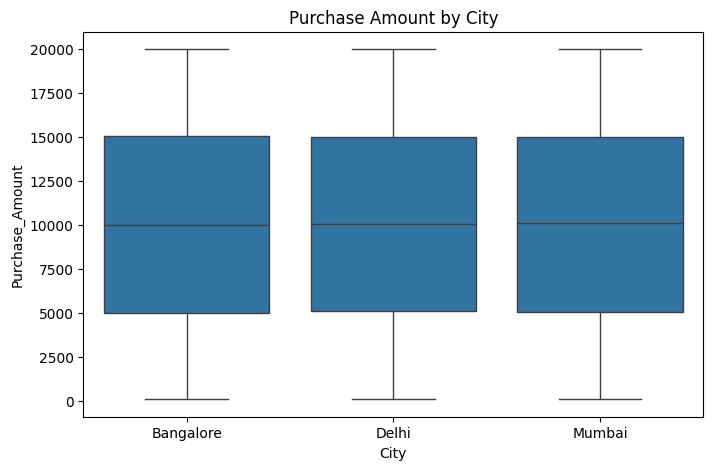

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='City', y='Purchase_Amount', data=df)
plt.title('Purchase Amount by City')
plt.show()

In [ ]:
Average Purchae By City

=== AVERAGE PURCHASE BY CITY ===
City
Bangalore    10028.580726
Delhi        10047.847536
Mumbai       10061.762281
Name: Purchase_Amount, dtype: float64


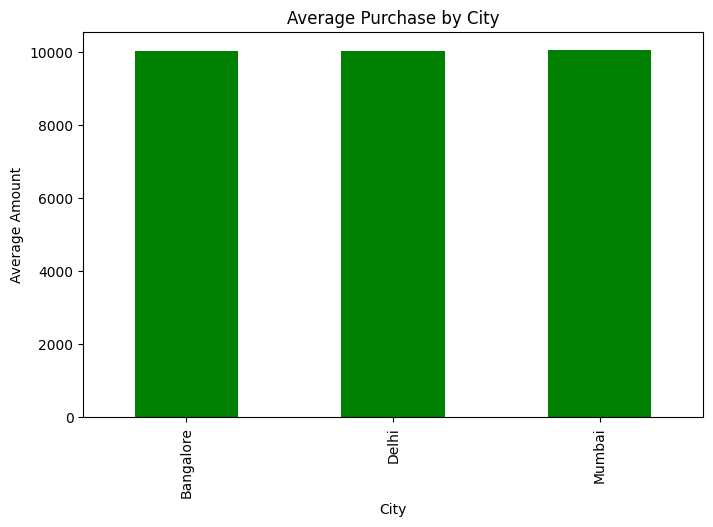

In [9]:
avg_city = df.groupby('City')['Purchase_Amount'].mean()
print("=== AVERAGE PURCHASE BY CITY ===")
print(avg_city)

plt.figure(figsize=(8,5))
avg_city.plot(kind='bar', color='green')
plt.title('Average Purchase by City')
plt.xlabel('City')
plt.ylabel('Average Amount')
plt.show()

In [ ]:
Age Group Analysis

Age_Group
<20      10070.974982
20-30    10034.600093
30-40    10057.460251
40-50    10016.917211
50+      10070.079783
Name: Purchase_Amount, dtype: float64


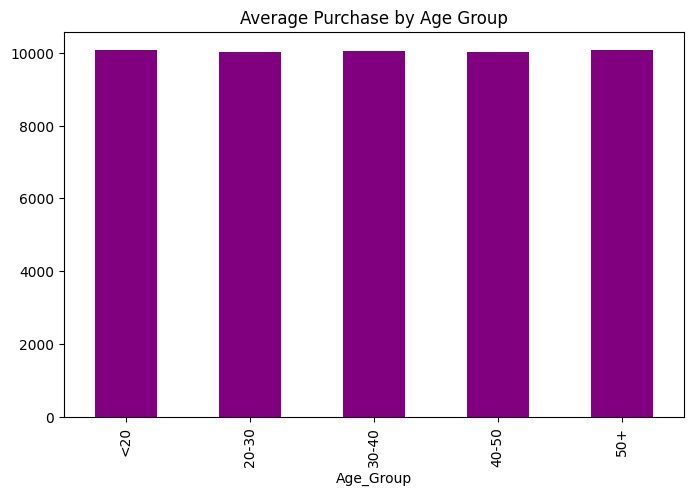

In [10]:
df['Age_Group'] = pd.cut(df['Age'], 
                   bins=[0,20,30,40,50,100],
                   labels=['<20','20-30','30-40','40-50','50+'])

age_purchase = df.groupby('Age_Group')['Purchase_Amount'].mean()
print(age_purchase)

plt.figure(figsize=(8,5))
age_purchase.plot(kind='bar', color='purple')
plt.title('Average Purchase by Age Group')
plt.show()

In [ ]:
Pie Chart city wise

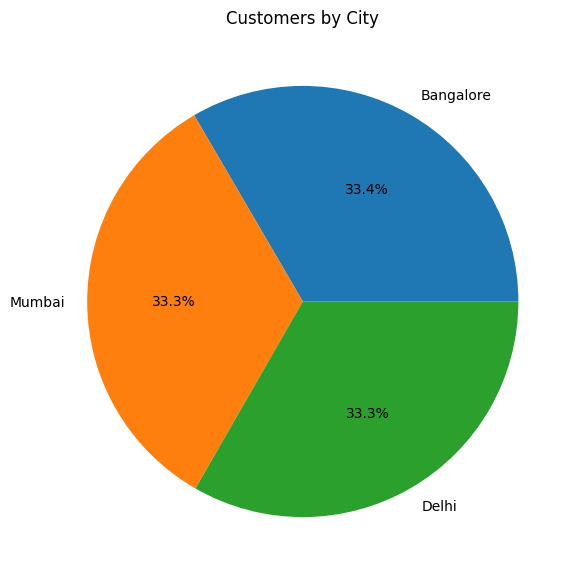

In [11]:
city_count = df['City'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(city_count, labels=city_count.index, autopct='%1.1f%%')
plt.title('Customers by City')
plt.show()

In [ ]:
Scatter Plot

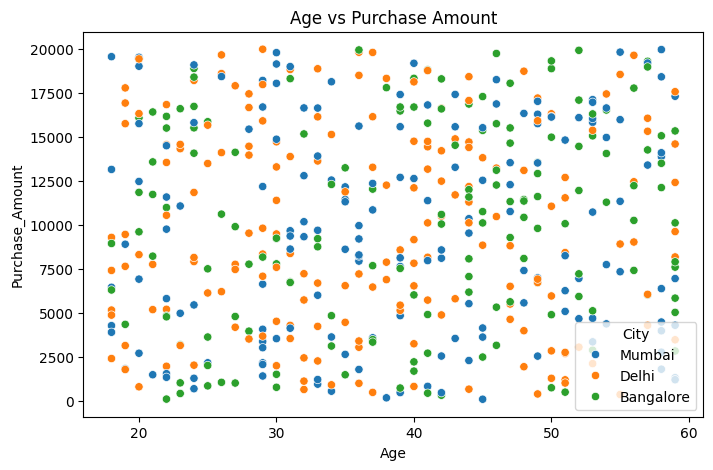

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Purchase_Amount', 
                hue='City', data=df.sample(500))
plt.title('Age vs Purchase Amount')
plt.show()

In [ ]:
Highest Buying city

In [13]:
best_city = df.groupby('City')['Purchase_Amount'].sum().idxmax()
print(f"Sabse Zyada Purchase karne wali City: {best_city}")

Sabse Zyada Purchase karne wali City: Mumbai


In [ ]:
Correlation

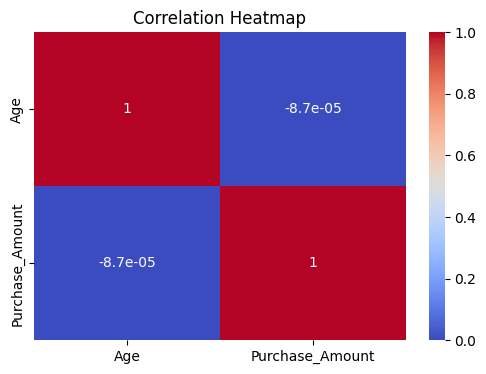

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Purchase_Amount']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
Dashboard

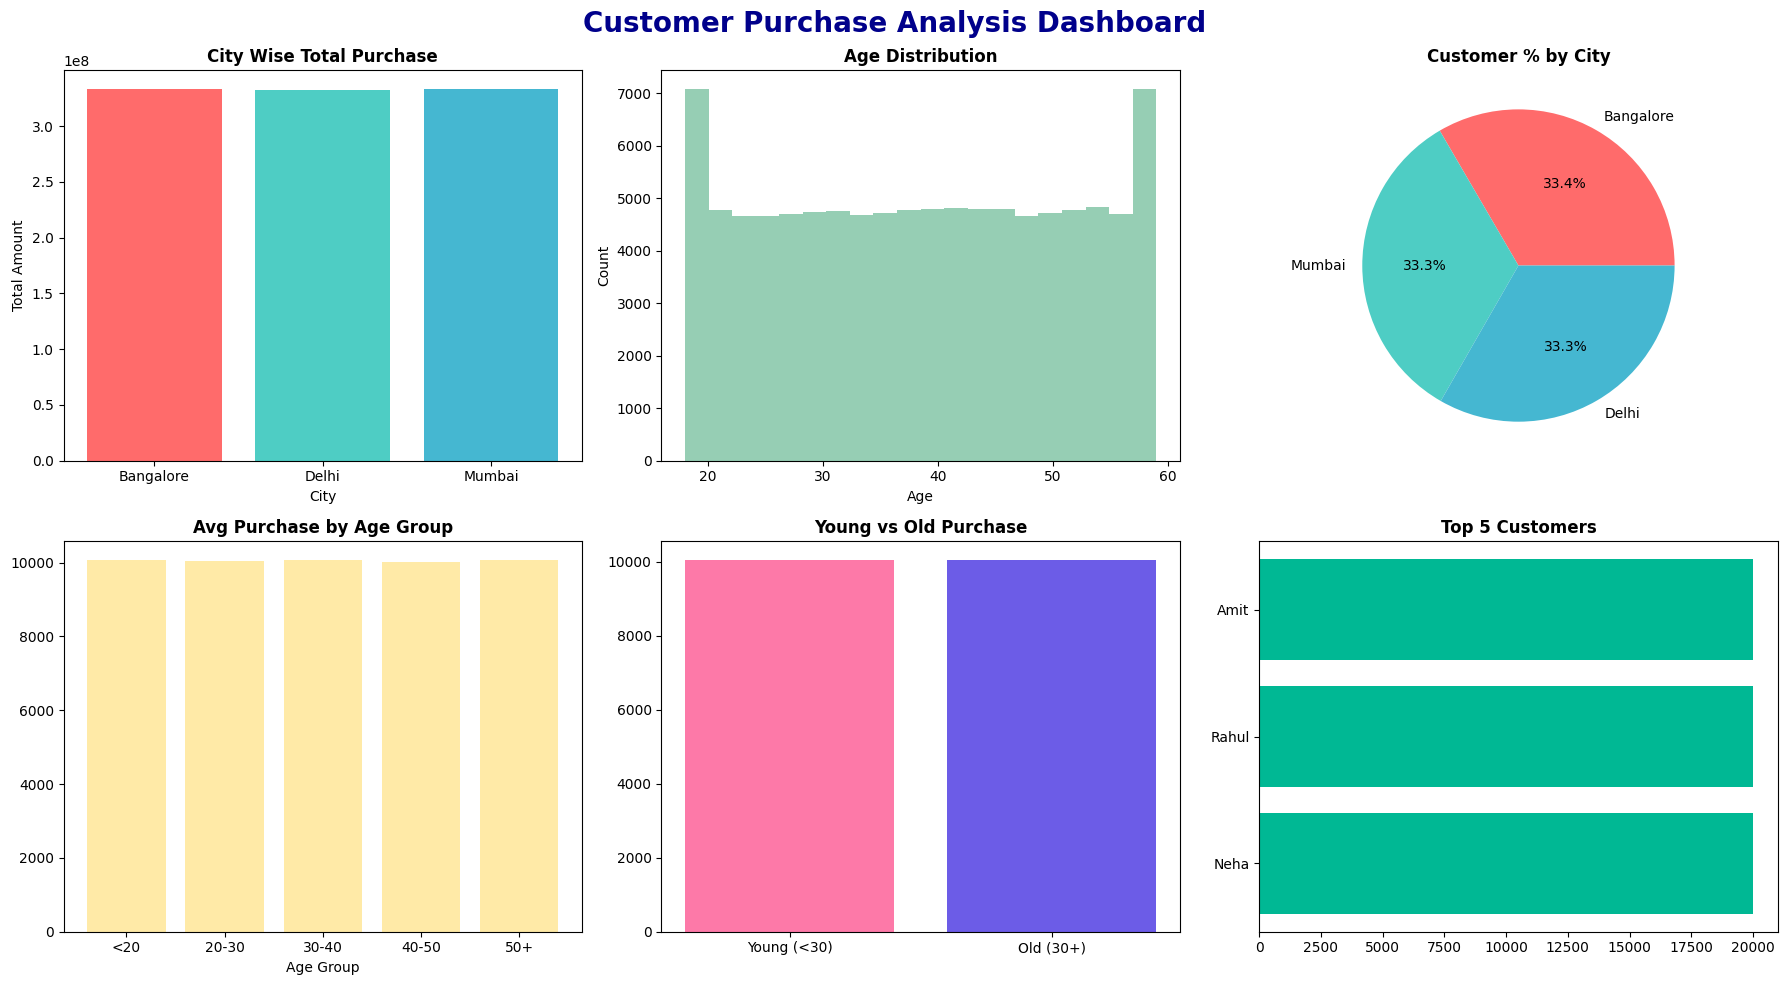

✅ Dashboard ready aur save ho gaya!


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Purchase Analysis Dashboard', 
              fontsize=20, fontweight='bold', color='darkblue')

# 1. City wise Total Purchase
city_sales = df.groupby('City')['Purchase_Amount'].sum()
axes[0,0].bar(city_sales.index, city_sales.values, 
              color=['#FF6B6B','#4ECDC4','#45B7D1'])
axes[0,0].set_title('City Wise Total Purchase', fontweight='bold')
axes[0,0].set_xlabel('City')
axes[0,0].set_ylabel('Total Amount')

# 2. Age Distribution
axes[0,1].hist(df['Age'], bins=20, color='#96CEB4')
axes[0,1].set_title('Age Distribution', fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')

# 3. Pie Chart
city_count = df['City'].value_counts()
axes[0,2].pie(city_count, labels=city_count.index, 
              autopct='%1.1f%%',
              colors=['#FF6B6B','#4ECDC4','#45B7D1'])
axes[0,2].set_title('Customer % by City', fontweight='bold')

# 4. Age Group Purchase
age_purchase = df.groupby('Age_Group')['Purchase_Amount'].mean()
axes[1,0].bar(age_purchase.index.astype(str), 
              age_purchase.values, color='#FFEAA7')
axes[1,0].set_title('Avg Purchase by Age Group', fontweight='bold')
axes[1,0].set_xlabel('Age Group')

# 5. Young vs Old
young = df[df['Age'] < 30]['Purchase_Amount'].mean()
old = df[df['Age'] >= 30]['Purchase_Amount'].mean()
axes[1,1].bar(['Young (<30)', 'Old (30+)'], 
              [young, old], color=['#FD79A8','#6C5CE7'])
axes[1,1].set_title('Young vs Old Purchase', fontweight='bold')

# 6. Top 5 Customers
top5 = df.nlargest(5, 'Purchase_Amount')
axes[1,2].barh(top5['Name'], top5['Purchase_Amount'], 
               color='#00B894')
axes[1,2].set_title('Top 5 Customers', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard ready aur save ho gaya!")

In [20]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas

c = canvas.Canvas("Customer_Analysis_Report.pdf", pagesize=letter)
c.setFont("Helvetica-Bold", 20)
c.drawString(150, 750, "Customer Purchase Analysis")
c.setFont("Helvetica", 14)
c.drawString(100, 700, f"Total Records: {len(df)}")
c.drawString(100, 670, f"Total Cities: 3")
c.drawString(100, 640, f"Average Purchase: Rs.{df['Purchase_Amount'].mean():.2f}")
c.drawImage("dashboard.png", 50, 200, width=500, height=350)
c.save()
print("✅ PDF Report ready!")

✅ PDF Report ready!


In [21]:
import os
print(os.getcwd())

C:\Users\user\Downloads
